# Neurons Analysis

This notebook mirrors the **`run_analyze`** pipeline from `run.py` step by step, with additional code for neuron distribution visualization. It performs:

1. **Concepts Categories** – Bar chart of concept counts by tag/category.
2. **AUROC by layer bin** – Scatter of AUROC by layer bin, colored by concept group (Amino Acid, Repeat, Blosum62, etc.).
3. **Neuron Average Scores per Group Across Layers** – Heatmap of mean attribution scores by layer and concept group (requires `component_recurrence` and `neurons_to_best_concepts`).
4. **Neuron Distribution Visualization** (optional) – Additional step to generate activation histograms (concept vs. other) for the best neuron per tag, as in Figure 9; requires saved activations (`--save_activations`).

**Before you run**: In the Config cell, choose `model_type` (e.g. `"esm3"` or `"esm-c"`), `counterfactual_type`, and `repeat_type` to match your experiment paths.

**Prerequisite**: Run `run.py` (concept experiment step) first to generate `concepts.csv` and `{model}_neurons_to_best_concepts.csv`. Figures are saved to the experiment results directory.

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path(os.getcwd()).resolve()
for _ in range(10):
    pkg = REPO_ROOT / "plms_repeats_circuits"
    if pkg.is_dir() and (pkg / "__init__.py").exists():
        break
    parent = REPO_ROOT.parent
    if REPO_ROOT == parent:
        raise RuntimeError("plms_repeats_circuits not found. cd to repo root.")
    REPO_ROOT = parent

sys.path.insert(0, str(REPO_ROOT))
script_dir = REPO_ROOT / "scripts" / "neurons_analysis_experiment"
sys.path.insert(0, str(script_dir))

from analyze import plot_concepts_categories, plot_auroc_scatter_columns_per_bin, plot_layer_cluster_heatmap_neurons

# Config
model_type = "esm3"  # or "esm-c"
counterfactual_type = "blosum"
repeat_type = "approximate"  

results_root = REPO_ROOT / "results"
exp_results_dir = results_root / "neurons_analysis" / model_type / counterfactual_type / repeat_type / "concept_exp_results"
exp_baseline_results_dir = results_root / "neurons_analysis" / model_type / counterfactual_type / repeat_type / "concept_exp_results_Baseline"

if not exp_results_dir.exists():
    raise FileNotFoundError(f"Experiment results dir not found: {exp_results_dir}. Run run_concept_experiment first.")

print(f"Exp results dir: {exp_results_dir}")
print(f"Model: {model_type}")

Exp results dir: /home/galkesten/plms-repeats-circuits/results/neurons_analysis/esm3/blosum/approximate/concept_exp_results
Model: esm3


## 1. Concepts Categories

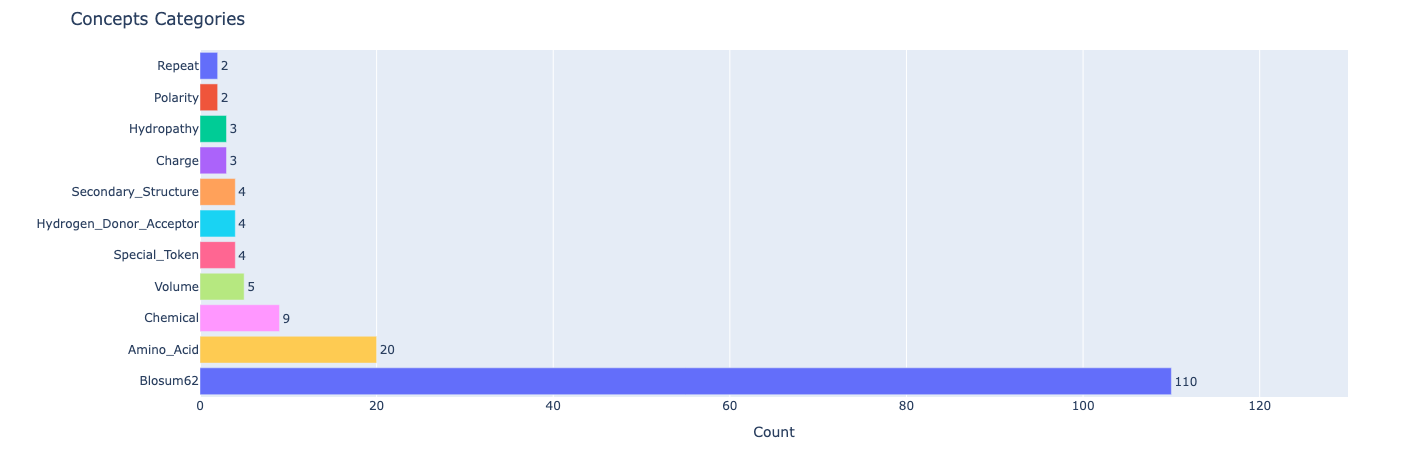

In [2]:
concepts_path = exp_results_dir / "concepts.csv"
if concepts_path.exists():
    concepts_df = pd.read_csv(concepts_path)
    fig1 = plot_concepts_categories(concepts_df, exp_results_dir)
    fig1.show()
else:
    print(f"Concepts file not found: {concepts_path}")

## 2. AUROC by layer bin

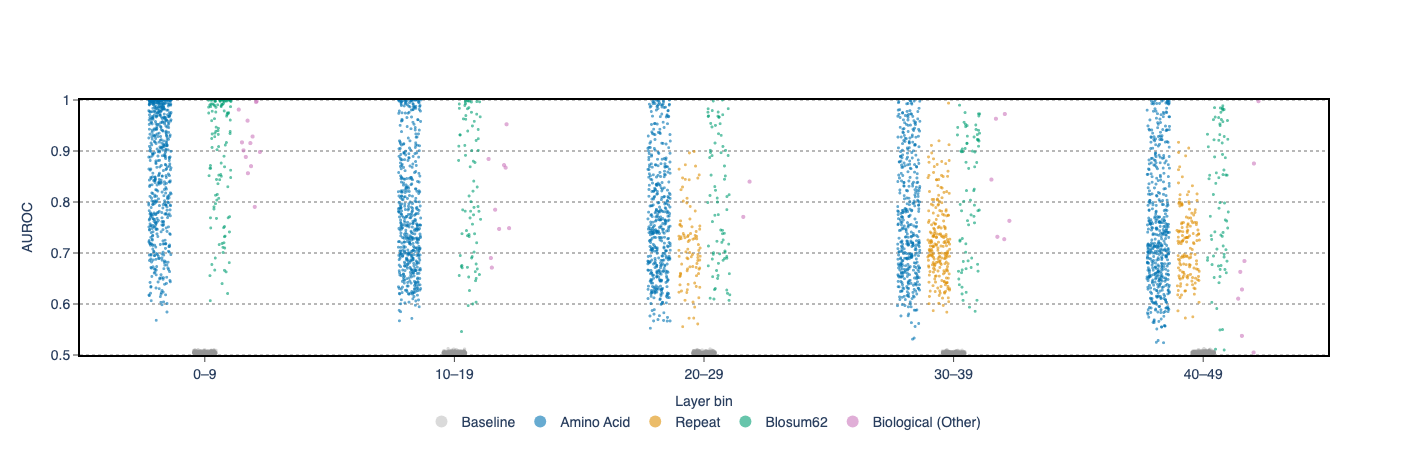

In [3]:
best_path = exp_results_dir / f"{model_type}_neurons_to_best_concepts.csv"
if best_path.exists():
    best_df = pd.read_csv(best_path)
    if "other_concept_names" in best_df.columns:
        best_df["other_concept_names"] = best_df["other_concept_names"].apply(
            lambda x: eval(x) if isinstance(x, str) else x
        )
    baseline_df = None
    if exp_baseline_results_dir:
        bp = Path(exp_baseline_results_dir) / f"{model_type}_neurons_to_best_concepts.csv"
        if bp.exists():
            baseline_df = pd.read_csv(bp)
    fig2 = plot_auroc_scatter_columns_per_bin(best_df, exp_results_dir, baseline_df=baseline_df)
    fig2.show()
else:
    print(f"Best concepts file not found: {best_path}")

## 3. Neuron Average Scores per Group Across Layers (Heatmap)

Heatmap of mean attribution scores by layer and concept group (Amino Acid, Biochemical Sim., Repeat). Requires `component_recurrence` and `neurons_to_best_concepts`.

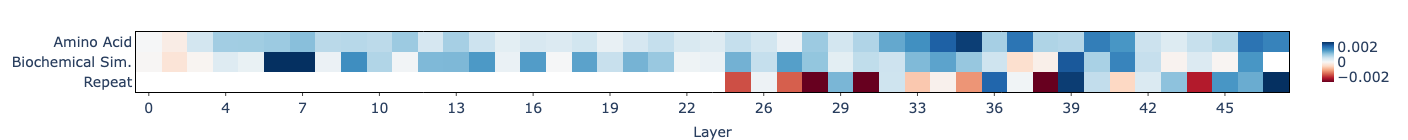

In [7]:
fig3 = plot_layer_cluster_heatmap_neurons(
    exp_results_dir=exp_results_dir,
    results_root=results_root,
    model_type=model_type,
    counterfactual_type=counterfactual_type,
    repeat_type=repeat_type,
)
if fig3 is not None:
    fig3.show()

## 4. Neuron Distribution Visualization (optional)

Plot activation histograms for neurons grouped by tag, or provide a manual list of neurons to visualize using manual_neurons_per_tag (one neuron per tag). This step requires activations_with_concepts.pt, generated by running with --save_activations.

One neuron is sampled from the top-k neurons for each tag, ranked by AUROC. The default is 1.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats

def plot_neurons_dist_for_tags(
    neurons_to_concepts_df,
    activations,
    concepts_global_indicies_dict,
    component_id_to_idx,
    seed=None,
    tags_to_plot=None,
    sub_w=5,
    sub_h=5,
    n_rows=None,
    n_cols=None,
    is_formal_title=False,
    manual_neurons_per_tag=None,
    top_k=1
):
    plt.close("all")

    FONT_SIZE = 10 
    
    rng = np.random.default_rng(seed)

    def has_no_other_concepts(x):
        if x is None:
            return True
        if isinstance(x, float) and np.isnan(x):
            return True
        return len(x) == 0

    tags = neurons_to_concepts_df["final_tag"].dropna().unique()

    selected = []
    for tag in tags:
        # Show a specific neuron
        if manual_neurons_per_tag and tag in manual_neurons_per_tag:
            cid = manual_neurons_per_tag[tag]

            if cid not in component_id_to_idx:
                continue

            row = neurons_to_concepts_df[
                neurons_to_concepts_df["component_id"] == cid
            ]

            if row.empty:
                continue

            row = row.iloc[0]

            selected.append({
                "tag": tag,
                "concept_name": row["concept_name"],
                "component_id": cid,
                "neuron_idx": component_id_to_idx[cid],
                "final_auroc": row["final_auroc"],
                "direction": "positive" if row["is_positive_direction"] else "negative",
                "layer": row["layer"],
                "neuron_idx_formal": row["neuron_idx"],
            })
            continue

        # Sampling logic
        tag_rows = neurons_to_concepts_df[
            neurons_to_concepts_df["final_tag"] == tag
        ].copy()

        tag_rows = tag_rows[
            tag_rows["concept_name"].isin(concepts_global_indicies_dict)
        ]

        if tag_rows.empty:
            continue

        tag_rows = tag_rows.sort_values("final_auroc", ascending=False)

        if tag == "Repeat":
            tag_rows = tag_rows[tag_rows["concept_name"].str.contains("repeat_tokens")]

        tag_rows = (
            tag_rows.head(top_k)
            .sample(frac=1, random_state=seed)
            .reset_index(drop=True)
        )

        for _, row in tag_rows.iterrows():
            cid = row["component_id"]
            if cid not in component_id_to_idx:
                continue

            selected.append({
                "tag": tag,
                "concept_name": row["concept_name"],
                "component_id": cid,
                "neuron_idx": component_id_to_idx[cid],
                "final_auroc": row["final_auroc"],
                "direction": "positive" if row["is_positive_direction"] else "negative",
                "layer": row["layer"],
                "neuron_idx_formal": row["neuron_idx"],
            })

            break

    if tags_to_plot is not None:
        selected = [p for p in selected if p["tag"] in tags_to_plot]

    if not selected:
        return None

  
    n = len(selected)

    if n_rows is None and n_cols is None:
        n_cols = int(np.ceil(np.sqrt(n)))
        n_rows = int(np.ceil(n / n_cols))
    elif n_rows is None:
        n_rows = int(np.ceil(n / n_cols))
    elif n_cols is None:
        n_cols = int(np.ceil(n / n_rows))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(sub_w * n_cols, sub_h * n_rows),
        dpi=300,
        squeeze=False,
    )
    axes = axes.flatten()

    n_tokens = activations.shape[0]

    # --------------------------------------------------
    # Plot neurons
    # --------------------------------------------------
    for ax, pair in zip(axes, selected):
        concept = pair["concept_name"]
        neuron_idx = pair["neuron_idx"]
        tag = pair["tag"]

        indices = concepts_global_indicies_dict[concept]
        valid_pos = indices.global_valid_positions_for_concept_on_proteins_with_repeats
        invalid_pos = indices.global_invalid_positions_for_concept_on_proteins_with_repeats

        if isinstance(valid_pos, torch.Tensor):
            valid_pos = valid_pos.cpu().numpy()
            invalid_pos = invalid_pos.cpu().numpy()

        all_pos = np.arange(n_tokens)
        valid_all = np.setdiff1d(all_pos, invalid_pos)
        non_concept_pos = np.setdiff1d(valid_all, valid_pos)

        act = (
            activations[:, neuron_idx].cpu().numpy()
            if isinstance(activations, torch.Tensor)
            else activations[:, neuron_idx]
        )

        a_concept = act[valid_pos]
        a_other = act[non_concept_pos]

        # Histograms
        h_other = ax.hist(a_other, bins=50, density=True, alpha=0.5)
        h_concept = ax.hist(a_concept, bins=50, density=True, alpha=0.7)

        # KDE
        if len(a_other) > 1:
            x = np.linspace(a_other.min(), a_other.max(), 200)
            ax.plot(x, stats.gaussian_kde(a_other)(x), color="gray")

        if len(a_concept) > 1:
            x = np.linspace(a_concept.min(), a_concept.max(), 200)
            ax.plot(x, stats.gaussian_kde(a_concept)(x), color="gray")

        # Title
        formal_tag_name = create_formal_tag_name(tag)
        title = formal_tag_name
        layer = pair["layer"]
        neuron_idx_formal = pair["neuron_idx_formal"]
        if is_formal_title==False:
            title = title+f"\nlayer{layer}_index{neuron_idx_formal}"
        ax.set_title(title)

        ax.set_xlabel("Activation")
        ax.set_ylabel("Density")

        ax.title.set_fontsize(FONT_SIZE)
        ax.xaxis.label.set_fontsize(FONT_SIZE)
        ax.yaxis.label.set_fontsize(FONT_SIZE)
        ax.tick_params(axis="both", labelsize=FONT_SIZE)

        formal_name = create_concept_formal_name(concept, tag)
        handles = [
            plt.Line2D([0], [0], color=h_other[2][0].get_facecolor(), lw=1),
            plt.Line2D([0], [0], color=h_concept[2][0].get_facecolor(), lw=1),
        ]

        labels = ["Other", formal_name]

        leg = ax.legend(
            handles,
            labels,
            loc="upper left",
            fontsize=FONT_SIZE,
            frameon=False,
            handlelength=0.8,   
            handletextpad=0.3, 
            borderpad=0.2,    
        )

        for t in leg.get_texts():
            t.set_fontsize(FONT_SIZE)

    # Hide unused axes
    for ax in axes[len(selected):]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig


def create_concept_formal_name(concept,tag):
    if tag =="Amino_Acid":
        new_name = concept.replace("_", " ")
        aa = new_name[0]
        new_name = f"{aa}"
        new_name = new_name.capitalize()
        return new_name
    else:
        if concept == "aromatic_ring_amino_acid":
            return "Aromatic Ring"
        if tag == "Blosum62":
            cluster = concept.split("blosum_cluster_")[1]
            new_name = f"{cluster}"
            return new_name
        if "amino_acid_IMGT" in concept:
            new_name = concept.replace("amino_acid_IMGT", "")
        elif "amino_acid_propensity" in concept:
            new_name = concept.replace("amino_acid_propensity", "")
        elif "amino_acid" in concept:
            new_name = concept.replace("amino_acid", "")
        else:
            new_name = concept
        new_name = new_name.replace("_", " ")
        new_name = new_name.title()
        return new_name

def create_formal_tag_name(tag):
    new_name = tag.replace("_", " ")
    new_name = new_name.title()
    return new_name

In [ ]:
activations_path = exp_results_dir / "activations_with_concepts.pt"
if activations_path.exists() and best_path.exists():
    import torch
    data = torch.load(activations_path, map_location="cpu")
    activations = data["activations_with_repeats"]
    concepts_global_indicies_dict = data["concepts_global_indicies_dict"]
    neuron_info_list = data['neuron_info_list']
    component_id_to_idx = {ni.component_id: i for i, ni in enumerate(neuron_info_list)}
else:
    if not activations_path.exists():
        print("Activations not found. plot_best_neuron_per_tag requires --save_activations.")

/tmp/ipykernel_255231/670254012.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(activations_path, map_location="cpu")


/tmp/ipykernel_255231/3683778756.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


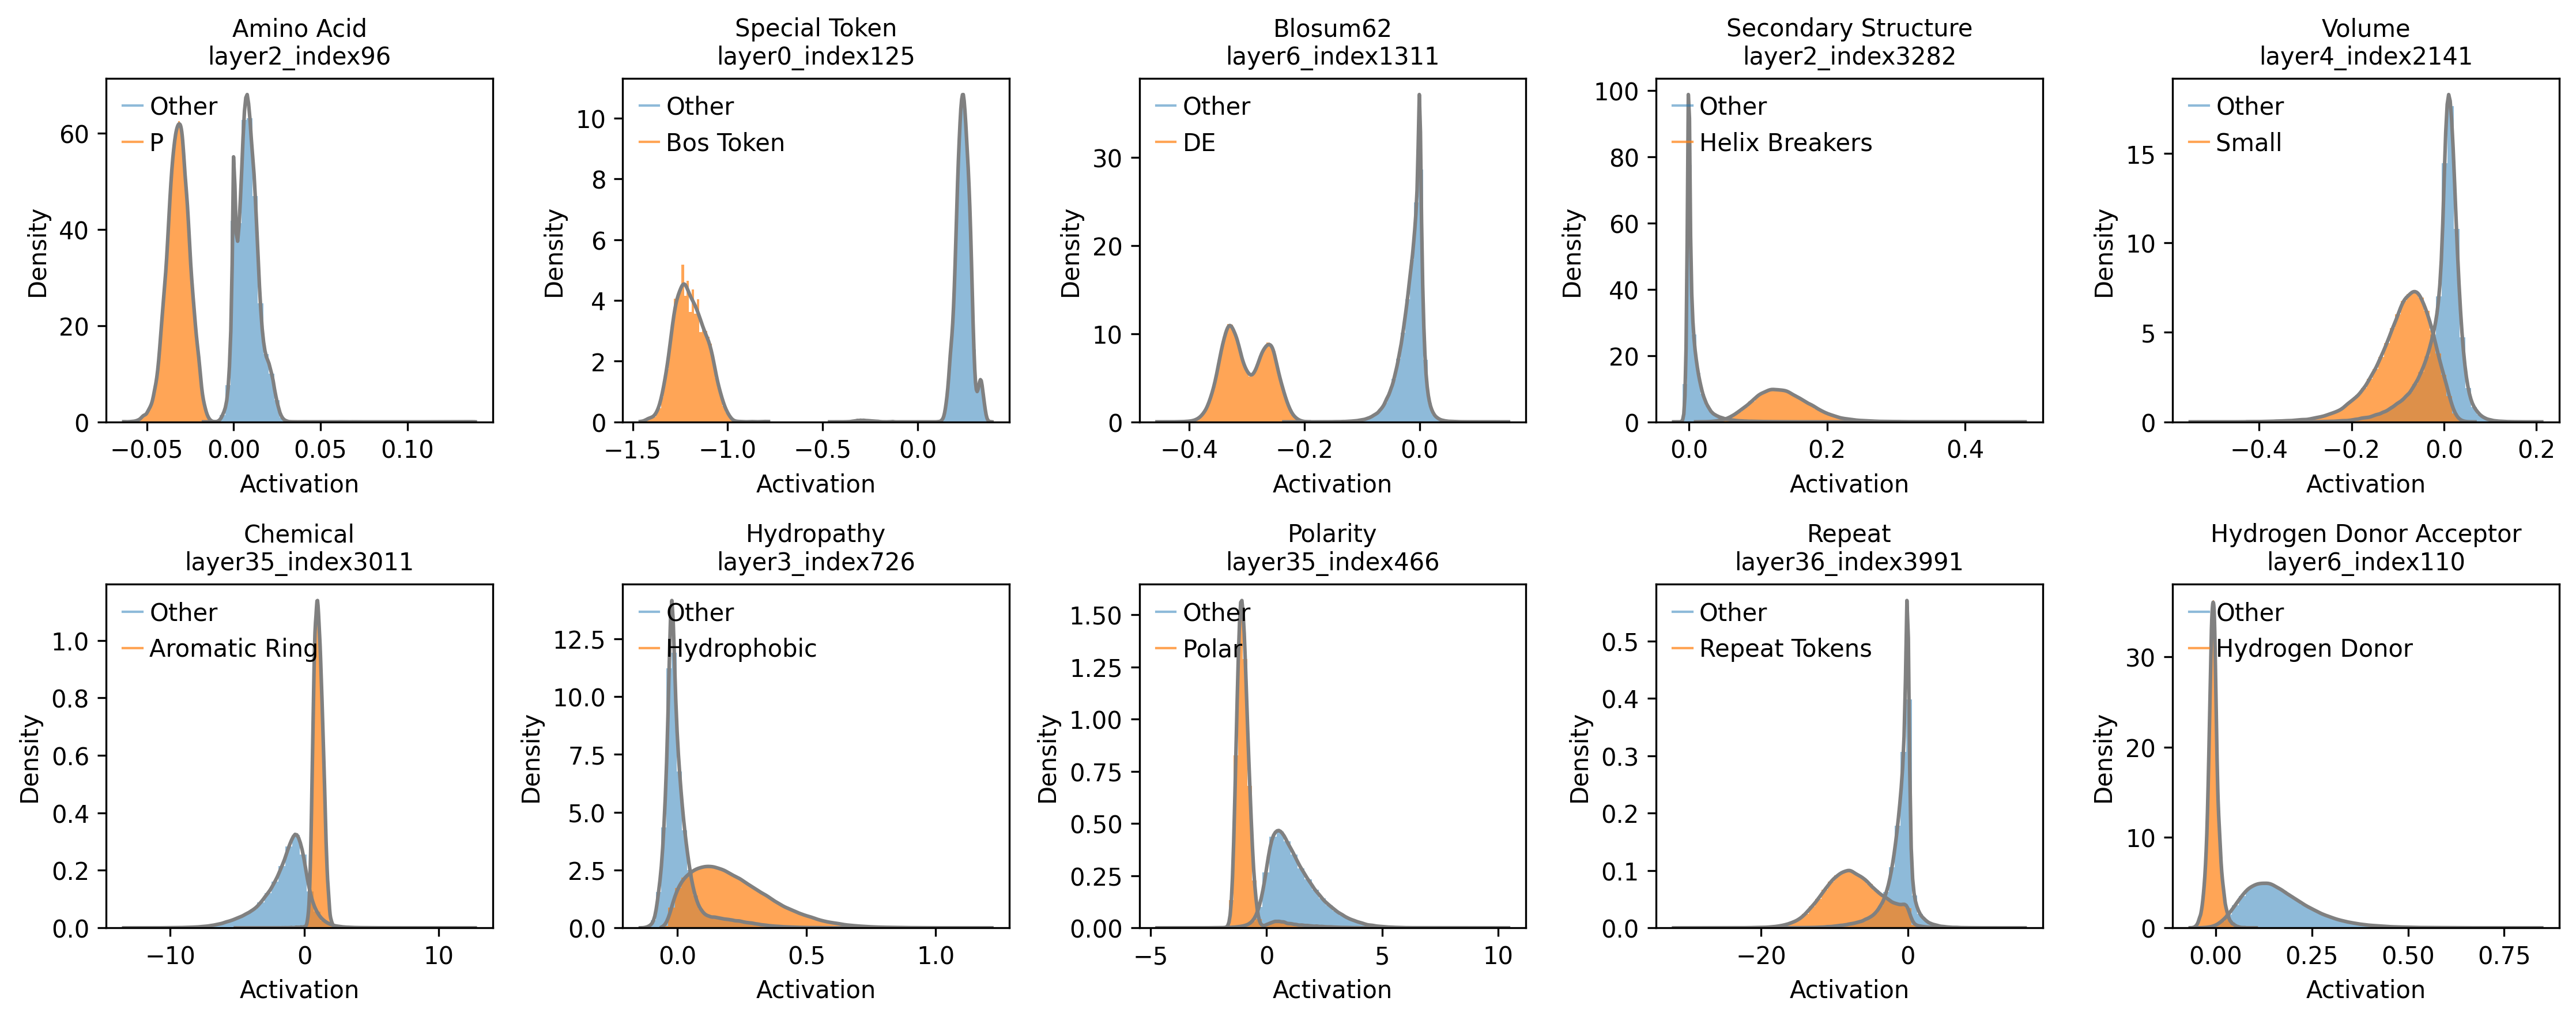

In [6]:
if activations !=None:
    fig = plot_neurons_dist_for_tags(
        neurons_to_concepts_df=best_df,
        activations=activations,
        concepts_global_indicies_dict=concepts_global_indicies_dict,
        component_id_to_idx=component_id_to_idx,
        seed=0,
        n_rows=2,
        n_cols=5,
        sub_w=3,
        sub_h=3,

    )
    if fig is not None:
        fig.show()